In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_raw = pd.read_csv("daily_platform_metrics_messy.csv")

In [3]:
df= df_raw.copy()

In [4]:
df

,Date,Platform,Visitors,Signups,Revenue
0,2024-02-21,WEBSITE,1055.0,38.0,15062.44
1,19-05-2024,Marketplace,773.0,32.0,13717.04
2,2024/04/05,marketplace,NaN,42.0,18490.06
3,01-04-2024,Mobile App,1038.0,44.0,23844.54
4,2024/06/05,WEBSITE,1967.0,51.0,"$61,256.04"
...,...,...,...,...,...
180,2024/04/11,website,967.0,46.0,20304.96
181,2024/03/20,WEBSITE,1131.0,46.0,24452.24
182,2024-04-19,Website,1043.0,62.0,18029.7
183,16/04/2024,MARKETPLACE,1046.0,50.0,20471.38


In [5]:
df["Date"] = pd.to_datetime(df["Date"] , format="mixed" , errors="coerce")

In [6]:
df["Platform"] = df["Platform"].str.strip().str.lower()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      185 non-null    datetime64[ns]
 1   Platform  185 non-null    object        
 2   Visitors  177 non-null    float64       
 3   Signups   178 non-null    float64       
 4   Revenue   174 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 7.4+ KB


In [8]:
df.describe()

,Date,Visitors,Signups
count,185,177.000000,178.000000
mean,2024-04-10 10:38:16.216216320,983.384181,46.095506
min,2024-01-01 00:00:00,536.000000,25.000000
25%,2024-02-15 00:00:00,796.000000,38.250000
50%,2024-04-08 00:00:00,964.000000,45.000000
75%,2024-05-26 00:00:00,1105.000000,52.000000
max,2024-12-06 00:00:00,2187.000000,74.000000
std,NaN,270.599963,10.991876


In [9]:
df.isnull().sum()

Date         0
Platform     0
Visitors     8
Signups      7
Revenue     11
dtype: int64

In [10]:
df["Visitors"] = df["Visitors"].fillna(df["Visitors"].mean())

In [11]:
df["Visitors"] = df["Visitors"].astype(int)

In [12]:
df

,Date,Platform,Visitors,Signups,Revenue
0,2024-02-21,website,1055,38.0,15062.44
1,2024-05-19,marketplace,773,32.0,13717.04
2,2024-04-05,marketplace,983,42.0,18490.06
3,2024-01-04,mobile app,1038,44.0,23844.54
4,2024-06-05,website,1967,51.0,"$61,256.04"
...,...,...,...,...,...
180,2024-04-11,website,967,46.0,20304.96
181,2024-03-20,website,1131,46.0,24452.24
182,2024-04-19,website,1043,62.0,18029.7
183,2024-04-16,marketplace,1046,50.0,20471.38


In [13]:
df = df.dropna().copy()

In [14]:
df.duplicated().sum()

np.int64(5)

In [15]:
df = df.drop_duplicates().copy()

In [16]:
df = df.reset_index(drop=True)

In [17]:
df = df.sort_values("Date")

In [18]:
df = df.reset_index(drop=True)

In [19]:
df["Revenue"] = df["Revenue"].apply(str).str.replace("$","").str.replace(",","")

In [20]:
df

,Date,Platform,Visitors,Signups,Revenue
0,2024-01-01,marketplace,804,47.0,17740.95
1,2024-01-03,web site,1000,46.0,23064.49
2,2024-01-04,mobile app,1038,44.0,23844.54
3,2024-01-05,web site,2127,51.0,67997.24
4,2024-01-05,web site,904,37.0,16640.82
...,...,...,...,...,...
157,2024-10-05,marketplace,1217,63.0,20128.73
158,2024-11-02,website,983,29.0,11922.73
159,2024-11-06,mobile app,1114,53.0,28238.26
160,2024-12-01,mobileapp,853,35.0,13042.83


In [21]:
df["Month"] = df["Date"].dt.to_period("M")

In [22]:
df["Revenue"] = pd.to_numeric(df["Revenue"] , errors="coerce")

In [23]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

In [31]:
x = [i+1 for i in range(len(monthly_revenue.values))]

In [32]:
monthly_revenue.values

array([470990.91, 539534.4 , 397291.7 , 504129.46, 610554.78, 700325.97,
        70649.11,  43563.42,  12317.37,  30752.42,  40160.99,  34009.27])

In [33]:
print(x)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


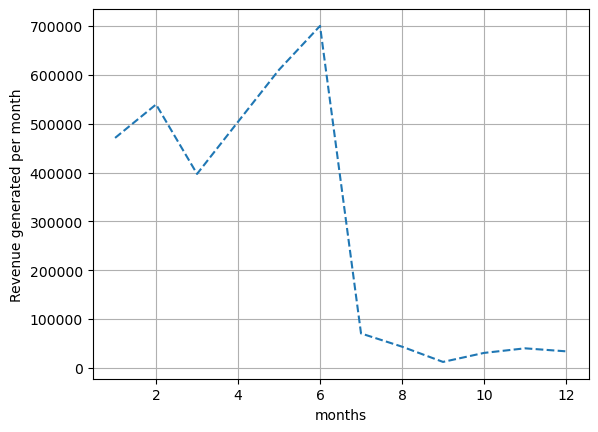

In [35]:
plt.plot(x,monthly_revenue.values,linestyle="--")
plt.grid(True)
plt.xlabel("months")
plt.ylabel("Revenue generated per month")
plt.show()

In [36]:
monthly_visitors = df.groupby("Month")["Visitors"].sum()

In [37]:
monthly_visitors

Month
2024-01    23012
2024-02    23575
2024-03    19887
2024-04    25951
2024-05    27919
2024-06    27641
2024-07     3883
2024-08     2176
2024-09      776
2024-10     1926
2024-11     2097
2024-12     1985
Freq: M, Name: Visitors, dtype: int64

In [38]:
monthly_signups = df.groupby("Month")["Signups"].sum()

In [39]:
monthly_signups_values = monthly_signups.values.astype(int)

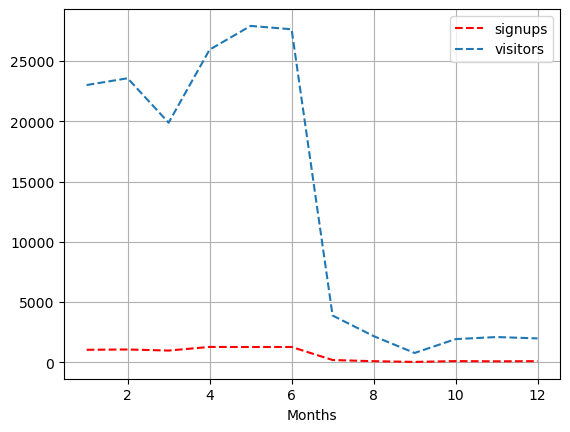

In [48]:
plt.plot(x , monthly_signups_values,color="red" ,label="signups" ,linestyle="--")
plt.grid(True)
plt.xlabel("Months")
plt.ylabel("")
plt.plot(x,monthly_visitors , label="visitors",linestyle="--")
plt.legend()
plt.show()

In [49]:
df

,Date,Platform,Visitors,Signups,Revenue,Month
0,2024-01-01,marketplace,804,47.0,17740.95,2024-01
1,2024-01-03,web site,1000,46.0,23064.49,2024-01
2,2024-01-04,mobile app,1038,44.0,23844.54,2024-01
3,2024-01-05,web site,2127,51.0,67997.24,2024-01
4,2024-01-05,web site,904,37.0,16640.82,2024-01
...,...,...,...,...,...,...
157,2024-10-05,marketplace,1217,63.0,20128.73,2024-10
158,2024-11-02,website,983,29.0,11922.73,2024-11
159,2024-11-06,mobile app,1114,53.0,28238.26,2024-11
160,2024-12-01,mobileapp,853,35.0,13042.83,2024-12


In [54]:
df["Platform"] = df["Platform"].str.replace(" ","")

In [55]:
df

,Date,Platform,Visitors,Signups,Revenue,Month
0,2024-01-01,marketplace,804,47.0,17740.95,2024-01
1,2024-01-03,website,1000,46.0,23064.49,2024-01
2,2024-01-04,mobileapp,1038,44.0,23844.54,2024-01
3,2024-01-05,website,2127,51.0,67997.24,2024-01
4,2024-01-05,website,904,37.0,16640.82,2024-01
...,...,...,...,...,...,...
157,2024-10-05,marketplace,1217,63.0,20128.73,2024-10
158,2024-11-02,website,983,29.0,11922.73,2024-11
159,2024-11-06,mobileapp,1114,53.0,28238.26,2024-11
160,2024-12-01,mobileapp,853,35.0,13042.83,2024-12


In [57]:
total_revenue_by_platforms = df.groupby("Platform")["Revenue"].sum()

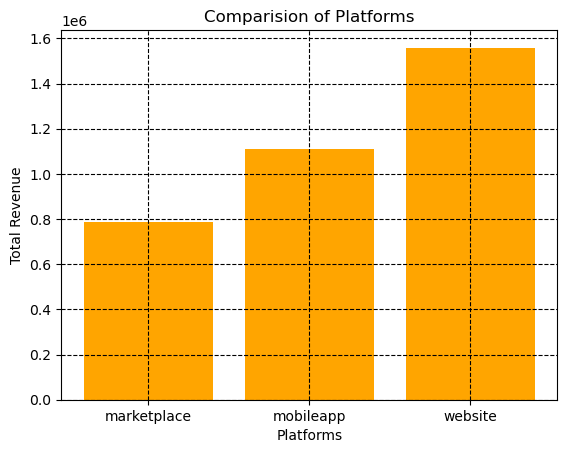

In [66]:
plt.bar(total_revenue_by_platforms.index , total_revenue_by_platforms.values , color="orange")
plt.xlabel("Platforms")
plt.ylabel("Total Revenue")
plt.title("Comparision of Platforms")
plt.grid(True ,linestyle="--" , color="black")
plt.show()

In [69]:
df["Weekday"] = df["Date"].dt.day_name()

In [73]:
total_revenue_by_weekday = df.groupby("Weekday")["Revenue"].sum().sort_values()

In [76]:
total_revenue_by_weekday = total_revenue_by_weekday.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

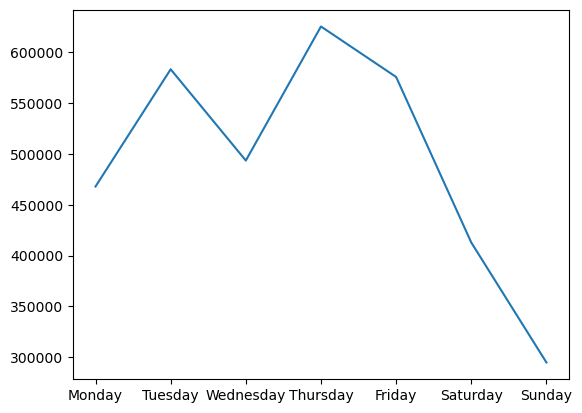

In [77]:
plt.plot(total_revenue_by_weekday.index , total_revenue_by_weekday.values)
plt.show()